In [ ]:
# Standard data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn utilities for preprocessing and evaluation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
)


print("Libraries imported successfully.")

In [30]:
# Load the dataset (Ensure CSV is in the same directory)
dataset = pd.read_csv("Social_Network_Ads.csv")

# Displaying first 5 rows to understand the structure
print("Dataset Head:")
display(dataset.head())

# Checking for missing values and data types
print("\nDataset Information Summary:")
dataset.info()

Dataset Head:


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0



Dataset Information Summary:
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          400 non-null    int64
 1   Gender           400 non-null    str  
 2   Age              400 non-null    int64
 3   EstimatedSalary  400 non-null    int64
 4   Purchased        400 non-null    int64
dtypes: int64(4), str(1)
memory usage: 15.8 KB


In [31]:
# Selecting 'Age' and 'EstimatedSalary' as independent variables (X)
# Selecting 'Purchased' as the dependent target variable (y)
X = dataset.iloc[:, [2, 3]].values 
y = dataset.iloc[:, -1].values

print(f"Features: {X.shape[1]} (Age, Salary)")
print(f"Observations: {X.shape[0]}")

Features: 2 (Age, Salary)
Observations: 400


In [32]:
# Stratify=y ensures the ratio of 'Purchased' vs 'Not Purchased' 
# remains the same in both training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"Training set: {len(X_train)} samples")
print(f"Testing set: {len(X_test)} samples")

Training set: 320 samples
Testing set: 80 samples


In [33]:
# KNN is a distance-based algorithm (Euclidean). 
# Without scaling, Salary (high range) would dominate Age (low range).
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Standardization applied to features.")

Standardization applied to features.


In [34]:
# Training an initial model with k=5 (Default)
baseline_knn = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
baseline_knn.fit(X_train, y_train)

# Making predictions on the test set
y_pred_base = baseline_knn.predict(X_test)

# Quick performance check
print(f"Baseline Accuracy (k=5): {accuracy_score(y_test, y_pred_base):.4f}")

Baseline Accuracy (k=5): 0.9000


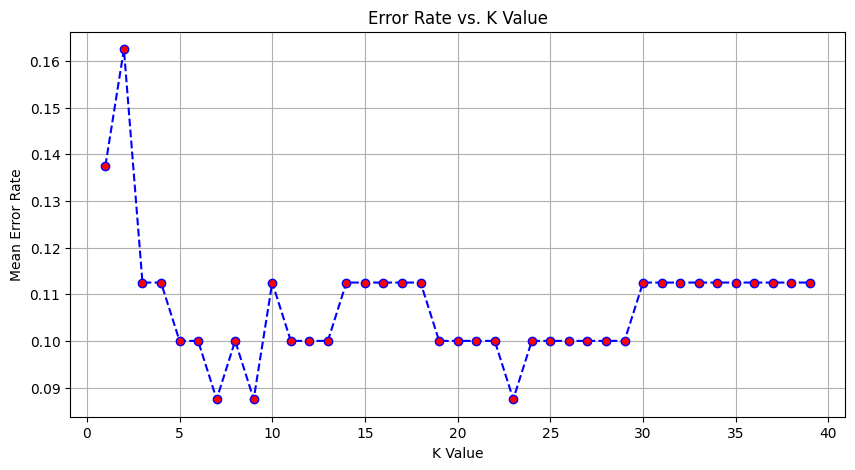

In [35]:
# Iterating through K values to find where the error rate stabilizes
error_rate = []

for k in range(1, 40):
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    pred_i = knn_temp.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

# Plotting the Error Rate
plt.figure(figsize=(10, 5))
plt.plot(range(1, 40), error_rate, color='blue', linestyle='dashed', marker='o', markerfacecolor='red')
plt.title('Error Rate vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Mean Error Rate')
plt.grid(True)
plt.show()

In [36]:
# Exhaustive search over specified parameter values for an estimator
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    KNeighborsClassifier(), 
    param_grid, 
    cv=10, 
    scoring='accuracy', 
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}
Best CV Score: 0.9125


=== FINAL MODEL EVALUATION ===
Final Test Accuracy: 0.9125

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93        51
           1       0.87      0.90      0.88        29

    accuracy                           0.91        80
   macro avg       0.90      0.91      0.91        80
weighted avg       0.91      0.91      0.91        80



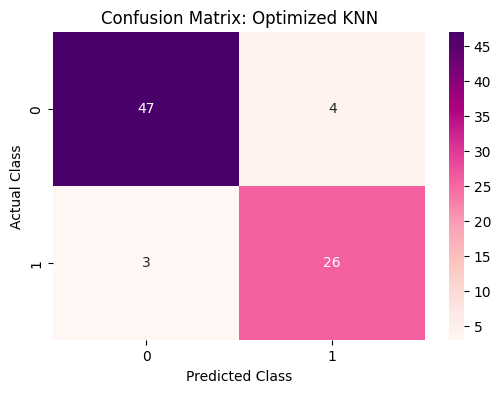

In [37]:
# Using the best estimator found by GridSearchCV
final_model = grid_search.best_estimator_
y_pred_final = final_model.predict(X_test)

# Detailed Metrics
print("=== FINAL MODEL EVALUATION ===")
print(f"Final Test Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

# Visualizing the Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu') # Changed color for variety
plt.title('Confusion Matrix: Optimized KNN')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

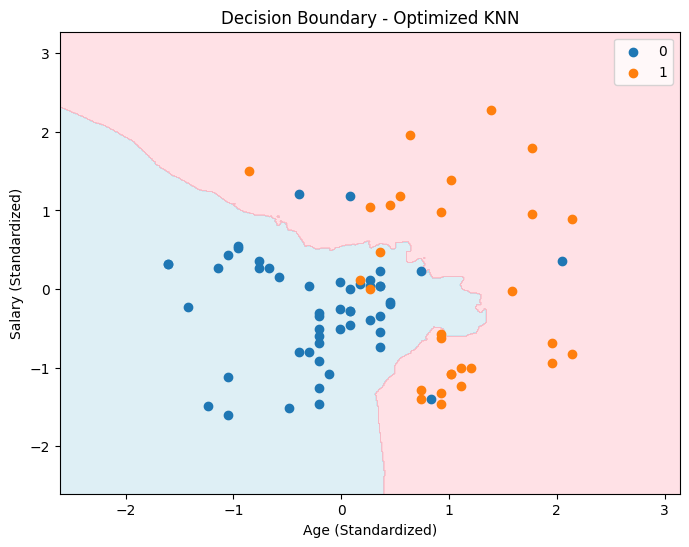

In [40]:
from matplotlib.colors import ListedColormap

def plot_decision_boundary(model, X_set, y_set, title):
    X1, X2 = np.meshgrid(
        np.arange(X_set[:, 0].min()-1, X_set[:, 0].max()+1, 0.01),
        np.arange(X_set[:, 1].min()-1, X_set[:, 1].max()+1, 0.01)
    )
    
    plt.figure(figsize=(8,6))
    plt.contourf(
        X1, X2,
        model.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
        alpha=0.4,
        cmap=ListedColormap(('lightblue','lightpink'))
    )
    
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(
            X_set[y_set == j, 0],
            X_set[y_set == j, 1],
            label=j
        )
        
    plt.title(title)
    plt.xlabel("Age (Standardized)")
    plt.ylabel("Salary (Standardized)")
    plt.legend()
    plt.show()

plot_decision_boundary(final_model, X_test, y_test,
                       "Decision Boundary - Optimized KNN")